# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.**
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
import os, time, json, gc, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from datasets import load_dataset

import tensorflow as tf
from tensorflow import keras

# — Sergey: Metal GPU adds dispatch overhead on small models (Embedding+Dense),
#   making them ~10x slower. Set False for P2-P3, True for P4 (BERT).
USE_GPU = True

if USE_GPU:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU enabled: {len(gpus)} device(s)")
    else:
        print("No GPU found — CPU only")
else:
    tf.config.set_visible_devices([], 'GPU')
    print("GPU disabled (CPU mode)")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

2026-04-11 20:40:52.213814: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775940052.462763      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775940052.533496      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775940053.114775      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775940053.114818      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775940053.114821      25 computation_placer.cc:177] computation placer alr

GPU enabled: 2 device(s)


Special provision for colab!

In [2]:
import sys
if "google.colab" in sys.modules:
    !pip install "transformers<5" tf-keras tensorflow "huggingface_hub<0.28"
    import os
    os.environ["CUDA_VISIBLE_DEVICES"] = ""  # force CPU
    COLAB_CPU = True
else:
    # Kaggle / other environments: also need transformers<5 for TF support
    !pip install "transformers<5" tf-keras "huggingface_hub<0.28" -q
    COLAB_CPU = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Load & Inspect

In [3]:
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total samples: 200,853


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


In [4]:
## special loading for colab
import requests
import json
from datasets import Dataset

URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

# download file
response = requests.get(URL)
data = [json.loads(line) for line in response.text.splitlines()]

# convert to Hugging Face dataset
huff_all = Dataset.from_list(data)

print(huff_all)
print(f"Columns: {huff_all.column_names}")
print(f"Total samples: {len(huff_all):,}")

df = huff_all.to_pandas()
df.head(3)

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total samples: 200,853


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


### Clean & Merge Categories

In [5]:
# Merge confusable categories identified in Milestone 1
LABEL_MAP = {
    "ARTS & CULTURE": "ARTS", "CULTURE & ARTS": "ARTS",
    "THE WORLDPOST": "WORLD NEWS", "WORLDPOST": "WORLD NEWS",
    "PARENTS": "PARENTING",
    "STYLE & BEAUTY": "STYLE",
    "TASTE": "FOOD & DRINK",
    "GREEN": "ENVIRONMENT",
    "COLLEGE": "EDUCATION",
    "HEALTHY LIVING": "HOME & LIVING",
}

print(f"Before merge: {df['category'].nunique()} categories, {len(df):,} rows")

df["category"] = df["category"].replace(LABEL_MAP)

# Combine headline + description
df["text"] = df.apply(
    lambda r: (r["headline"] + " [SEP] " + r["short_description"]).strip()
    if pd.notna(r["short_description"]) and r["short_description"].strip()
    else r["headline"],
    axis=1,
)

# Drop empty headlines
empty_mask = df["headline"].isna() | (df["headline"].str.strip() == "")
print(f"Empty headlines dropped: {empty_mask.sum()}")
df = df[~empty_mask].copy()

# Remove exact duplicates (headline + short_description)
before_dedup = len(df)
df = df.drop_duplicates(subset=["headline", "short_description"], keep="first")
print(f"Duplicates removed: {before_dedup - len(df)}")

print(f"After cleaning: {df['category'].nunique()} categories, {len(df):,} rows")

Before merge: 41 categories, 200,853 rows
Empty headlines dropped: 6
Duplicates removed: 484
After cleaning: 31 categories, 200,363 rows


### Class Distribution

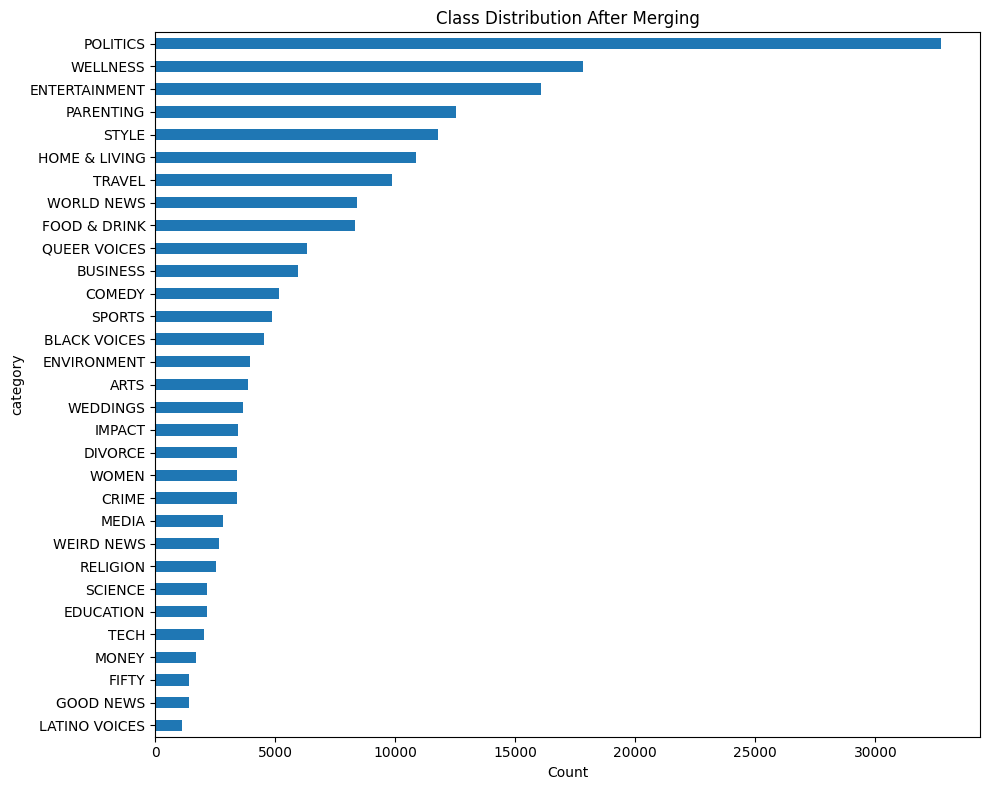

Categories: 31
Largest:  POLITICS (32,721)
Smallest: LATINO VOICES (1,129)
Median:   3,876
Imbalance ratio (max/min): 29.0x


In [6]:
counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
counts.plot.barh(ax=ax)
ax.set_xlabel("Count")
ax.set_title("Class Distribution After Merging")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Categories: {len(counts)}")
print(f"Largest:  {counts.index[0]} ({counts.iloc[0]:,})")
print(f"Smallest: {counts.index[-1]} ({counts.iloc[-1]:,})")
print(f"Median:   {int(counts.median()):,}")
print(f"Imbalance ratio (max/min): {counts.iloc[0] / counts.iloc[-1]:.1f}x")

### Stratified Train / Val / Test Splits

In [7]:
texts = np.array(df["text"].tolist(), dtype=object)
labels = df["category"].tolist()

# Encode labels
class_names = sorted(set(labels))
label2id = {name: i for i, name in enumerate(class_names)}
y = np.array([label2id[c] for c in labels])
num_classes = len(class_names)

# 80/10/10 stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Classes: {num_classes}")

# Compute class weights for imbalanced training
cw = compute_class_weight("balanced", classes=np.arange(num_classes), y=y_train)
class_weights = dict(enumerate(cw))
print(f"Class weight range: [{min(cw):.3f}, {max(cw):.3f}]")

Train: 160,290  Val: 20,036  Test: 20,037
Classes: 31
Class weight range: [0.198, 5.726]


### Text Length Distribution

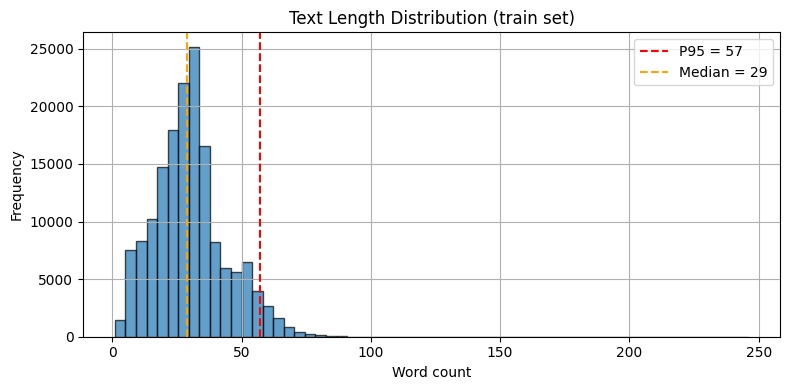

Mean:   30.2
Median: 29
P95:    57
P99:    68
Max:    246


In [8]:
word_counts = pd.Series([len(t.split()) for t in X_train])

fig, ax = plt.subplots(figsize=(8, 4))
word_counts.hist(bins=60, ax=ax, edgecolor="black", alpha=0.7)
ax.axvline(word_counts.quantile(0.95), color="red", ls="--", label=f"P95 = {word_counts.quantile(0.95):.0f}")
ax.axvline(word_counts.median(), color="orange", ls="--", label=f"Median = {word_counts.median():.0f}")
ax.set_xlabel("Word count")
ax.set_ylabel("Frequency")
ax.set_title("Text Length Distribution (train set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean:   {word_counts.mean():.1f}")
print(f"Median: {word_counts.median():.0f}")
print(f"P95:    {word_counts.quantile(0.95):.0f}")
print(f"P99:    {word_counts.quantile(0.99):.0f}")
print(f"Max:    {word_counts.max()}")

### Sample Examples

In [9]:
for i in range(5):
    print(f"[{class_names[y_train[i]]}] {X_train[i][:120]}...")
    print()

[POLITICS] Remembering Mario Cuomo [SEP] It was odd, but out of the blue, I found myself thinking about Mario Cuomo just days befor...

[POLITICS] White House (Falsely) Downplays Political Adviser’s Role On NSC [SEP] Trump’s spokesman misrepresented changes that elev...

[POLITICS] Donald Trump Promised Ten Of These Things, Guess Which One He Actually Did [SEP] OK, this isn't actually one of those li...

[TRAVEL] Tech-Free Havens: The World's Best Unplugged Getaways (PHOTOS) [SEP] Plenty of hooked-up travelers will check work e-mai...

[ENTERTAINMENT] These Are The Real People Who Follow The Jedi Religion [SEP] "American Jedi" documents a universal path of pain, growth ...



### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible.

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. We loaded the HuffPost News Category Dataset (200,853 records, 41 categories) from a JSON mirror on HuggingFace using `load_dataset("json", ...)`. Three cleaning steps were applied: (1) merged 8 groups of overlapping categories identified in Milestone 1 (e.g., ARTS & CULTURE / CULTURE & ARTS → ARTS, PARENTS → PARENTING), reducing 41 categories to 31; (2) dropped 6 rows with empty headlines; (3) removed 484 exact duplicate (headline + short_description) pairs. Final cleaned dataset: 200,363 rows across 31 categories.

2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. Each sample's text was formed by concatenating the headline and short_description with a `[SEP]` separator; when the description was missing (~9.8% of records), the headline alone was used. A `TextVectorization` layer was configured with `max_tokens=20,000` and `output_sequence_length=64`, chosen based on the computed P95 word count of 57 words in the training set (mean 30.2, median 29). The layer was adapted on training text only, then applied once to produce integer-encoded numpy arrays (shape 160,290 × 64), avoiding repeated tokenization during training. No text augmentation was applied at this stage.

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. The cleaned dataset was split into train (80%), validation (10%), and test (10%) subsets using two successive calls to `train_test_split` with `random_state=42` and `stratify=y` to preserve class proportions. This produced 160,290 training, 20,036 validation, and 20,037 test samples. Deduplication was performed before splitting to prevent data leakage — any exact (headline + description) duplicates that might have landed in both train and test were removed beforehand. The stratified split ensures that even the smallest class (LATINO VOICES, 1,129 total) is proportionally represented in all three subsets.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. After merging, the largest class is POLITICS (32,721 samples) and the smallest is LATINO VOICES (1,129), giving an imbalance ratio of 29.0x. The median class size is 3,876, well below the mean (~6,463), confirming a long-tailed distribution visible in the bar chart. To address this, we computed per-class weights using `sklearn`'s `compute_class_weight("balanced")`, which produced weights ranging from 0.198 (for POLITICS) to 5.726 (for LATINO VOICES). These weights are passed to `model.fit()` via the `class_weight` parameter so the loss function penalizes errors on minority classes proportionally more.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [10]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

RESULTS_FILE = "results/ms2_results.json"
results = {}

def save_results():
    os.makedirs(os.path.dirname(RESULTS_FILE), exist_ok=True)
    with open(RESULTS_FILE, "w") as f:
        json.dump(results, f, indent=2)
    print(f"Results saved ({len(results)} models)")

def load_results():
    global results
    try:
        with open(RESULTS_FILE) as f:
            results = json.load(f)
        if results:
            print(f"Restored {len(results)} results from {RESULTS_FILE}:")
            for name, r in results.items():
                print(f"  {name}: test_acc={r['test_acc']:.4f}, test_f1={r['test_f1']:.4f}")
    except FileNotFoundError:
        pass

def evaluate_model(model, name, X_te, y_te, hist, train_time, batch_size=512):
    y_pred = model.predict(X_te, batch_size=batch_size, verbose=0).argmax(axis=-1)
    test_acc = float(np.mean(y_pred == y_te))
    test_f1 = float(f1_score(y_te, y_pred, average="macro"))

    val_losses = hist.history["val_loss"]
    best_epoch = int(np.argmin(val_losses)) + 1
    val_acc = float(hist.history["val_accuracy"][best_epoch - 1])
    val_loss = float(val_losses[best_epoch - 1])

    results[name] = {
        "val_acc": val_acc, "val_loss": val_loss, "best_epoch": best_epoch,
        "test_acc": test_acc, "test_f1": test_f1,
        "params": model.count_params(), "train_time": train_time,
    }
    save_results()

    print(f"=== {name} ===")
    print(f"Best epoch:  {best_epoch}")
    print(f"Val acc:     {val_acc:.4f}  |  Val loss: {val_loss:.4f}")
    print(f"Test acc:    {test_acc:.4f}  |  Test F1:  {test_f1:.4f}")
    print(f"Params:      {model.count_params():,}")
    print(f"Train time:  {format_hms(train_time)}")
    return y_pred

# Auto-restore on cell run
load_results()

In [11]:
#Saving the confusion matrix confused pairs to a file as well for reporting later

In [12]:
def save_confused_pairs(confused,model_name, top_n=10):

    confused.sort(reverse=True)
    file_path="confused_pairs.csv"
    if top_n is not None:
        confused = confused[:top_n]

    new_df = pd.DataFrame(
        confused,
        columns=["Count", "True Label", "Predicted Label"]
    )
    new_df["Model"] = model_name
    new_df = new_df[["Model", "Count", "True Label", "Predicted Label"]]

    file_exists = os.path.exists(file_path)

    new_df.to_csv(
        file_path,
        mode="a",
        header=not file_exists,
        index=False
    )

    return new_df

### Tokenization

In [13]:
MAX_TOKENS = 20_000
SEQ_LEN = 64  # based on P95 word count from the distribution above
BATCH = 256

text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_sequence_length=SEQ_LEN,
    standardize="lower_and_strip_punctuation",
)
text_vectorizer.adapt(X_train)

vocab_size = text_vectorizer.vocabulary_size()
print(f"Vocabulary size: {vocab_size:,}")
print(f"Sequence length: {SEQ_LEN}")

# Pre-vectorize once into numpy — avoids re-tokenizing every epoch
X_train_vec = text_vectorizer(X_train).numpy()
X_val_vec   = text_vectorizer(X_val).numpy()
X_test_vec  = text_vectorizer(X_test).numpy()

print(f"Vectorized shapes — train: {X_train_vec.shape}, val: {X_val_vec.shape}, test: {X_test_vec.shape}")

I0000 00:00:1775940112.189520      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775940112.195401      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Vocabulary size: 20,000
Sequence length: 64
Vectorized shapes — train: (160290, 64), val: (20036, 64), test: (20037, 64)


### Build & Compile Baseline

In [14]:
baseline = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="baseline_emb_avg")

baseline.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline.summary()

Model: "baseline_emb_avg"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Baseline

In [15]:
es = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

t0 = time.time()
hist_baseline = baseline.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=50,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1,
)
train_time = time.time() - t0
print(f"Training time: {format_hms(train_time)}")

Epoch 1/50


I0000 00:00:1775940118.753199     150 service.cc:152] XLA service 0x7f6608001e40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775940118.753234     150 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775940118.753238     150 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775940119.003629     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


 57/627 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0300 - loss: 3.4080

I0000 00:00:1775940120.033527     150 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


627/627 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.0660 - loss: 3.3036 - val_accuracy: 0.3094 - val_loss: 2.6235
Epoch 2/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3529 - loss: 2.5756 - val_accuracy: 0.4682 - val_loss: 2.0727
Epoch 3/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4760 - loss: 2.0251 - val_accuracy: 0.5150 - val_loss: 1.8511
Epoch 4/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5338 - loss: 1.7300 - val_accuracy: 0.5337 - val_loss: 1.7537
Epoch 5/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5696 - loss: 1.5439 - val_accuracy: 0.5409 - val_loss: 1.7126
Epoch 6/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5952 - loss: 1.4072 - val_accuracy: 0.5445 - val_loss: 1.6953
Epoch 7/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6154 - loss: 1.2970 - val_accuracy: 0.5488 - val_loss: 1.6827
Epoch 8/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6325 - loss: 1.2032 - val_accuracy: 0.5518 - val_

### Learning Curves & Evaluation

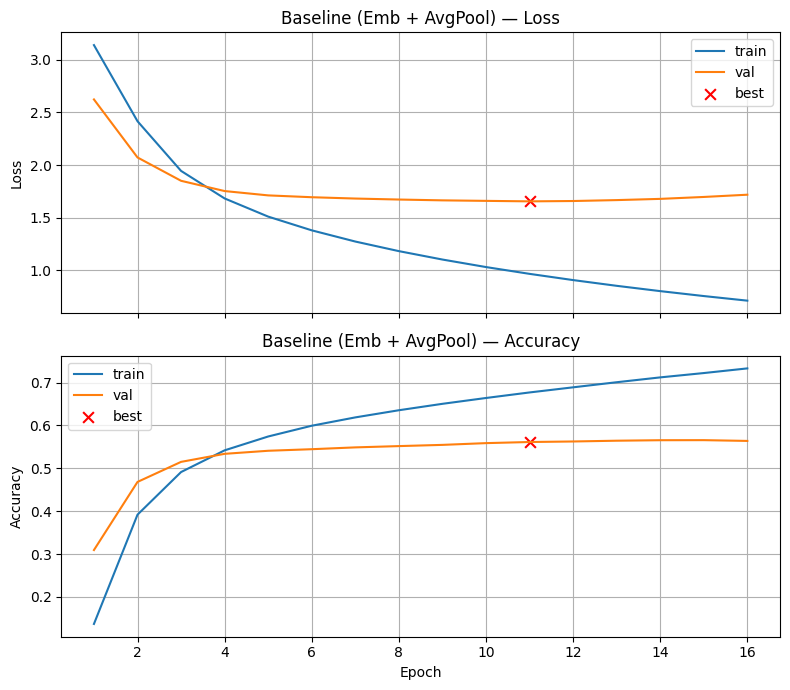

Best epoch: 11
Val loss:   1.6560
Val acc:    0.5613


In [16]:
def plot_learning_curves(hist, title):
    val_losses = hist.history["val_loss"]
    min_val_loss = min(val_losses)
    best_epoch = val_losses.index(min_val_loss)
    val_acc_best = hist.history["val_accuracy"][best_epoch]

    epochs = range(1, len(val_losses) + 1)
    fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

    axs[0].plot(epochs, hist.history["loss"], label="train")
    axs[0].plot(epochs, val_losses, label="val")
    axs[0].scatter(best_epoch + 1, min_val_loss, color="red", marker="x", s=60, label="best")
    axs[0].set_title(f"{title} — Loss")
    axs[0].set_ylabel("Loss")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(epochs, hist.history["accuracy"], label="train")
    axs[1].plot(epochs, hist.history["val_accuracy"], label="val")
    axs[1].scatter(best_epoch + 1, val_acc_best, color="red", marker="x", s=60, label="best")
    axs[1].set_title(f"{title} — Accuracy")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"Best epoch: {best_epoch + 1}")
    print(f"Val loss:   {min_val_loss:.4f}")
    print(f"Val acc:    {val_acc_best:.4f}")
    return best_epoch + 1, val_acc_best

best_ep, val_acc = plot_learning_curves(hist_baseline, "Baseline (Emb + AvgPool)")

In [17]:
y_pred_base = evaluate_model(baseline, "Baseline (Emb+AvgPool)", X_test_vec, y_test, hist_baseline, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (1 models)
=== Baseline (Emb+AvgPool) ===
Best epoch:  11
Val acc:     0.5613  |  Val loss: 1.6560
Test acc:    0.5638  |  Test F1:  0.4987
Params:      1,286,175
Train time:  00:00:37

               precision    recall  f1-score   support

         ARTS       0.44      0.49      0.46       388
 BLACK VOICES       0.48      0.41      0.44       453
     BUSINESS       0.48      0.45      0.47       594
       COMEDY       0.34      0.47      0.39       517
        CRIME       0.42      0.58      0.48       340
      DIVORCE       0.72      0.77      0.74       342
    EDUCATION       0.37      0.47      0.41       215
ENTERTAINMENT       0.79      0.44      0.56      1606
  ENVIRONMENT       0.42      0.49      0.45       394
        FIFTY       0.20      0.35      0.25       140
 FOOD & DRINK       0.64      0.77      0.70       832
    GOOD NEWS       0.12      0.54      0.19       139
HOME & LIVING       0.55      0.39      0.46      1085
       IMPACT       0.23     

In [18]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

Top 10 confused pairs (true -> predicted, count):
  HOME & LIVING             -> WELLNESS                   (210)
  ENTERTAINMENT             -> COMEDY                     (196)
  POLITICS                  -> WORLD NEWS                 (188)
  POLITICS                  -> MEDIA                      (128)
  POLITICS                  -> COMEDY                     (123)
  POLITICS                  -> BUSINESS                   (119)
  POLITICS                  -> RELIGION                   (108)
  POLITICS                  -> CRIME                      (102)
  POLITICS                  -> IMPACT                     (98)
  POLITICS                  -> ENVIRONMENT                (93)


In [19]:
save_confused_pairs(confused,model_name="baseline_emb_avg", top_n=10)

,Model,Count,True Label,Predicted Label
0,baseline_emb_avg,210,HOME & LIVING,WELLNESS
1,baseline_emb_avg,196,ENTERTAINMENT,COMEDY
2,baseline_emb_avg,188,POLITICS,WORLD NEWS
3,baseline_emb_avg,128,POLITICS,MEDIA
4,baseline_emb_avg,123,POLITICS,COMEDY
5,baseline_emb_avg,119,POLITICS,BUSINESS
6,baseline_emb_avg,108,POLITICS,RELIGION
7,baseline_emb_avg,102,POLITICS,CRIME
8,baseline_emb_avg,98,POLITICS,IMPACT
9,baseline_emb_avg,93,POLITICS,ENVIRONMENT


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. The baseline is a `Sequential` model: `Embedding(20,000 × 64)` → `GlobalAveragePooling1D` → `Dense(64, relu)` → `Dense(31, softmax)`, totaling 1,286,175 parameters. This architecture was chosen because it matches the assignment's recommended text baseline (Embedding → GlobalAveragePooling → Dense → Softmax). GlobalAveragePooling1D averages all token embeddings into a single 64-dim vector, discarding word order — intentionally simple to establish a performance floor. The model takes pre-vectorized integer sequences as input (shape: batch × 64).

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. Training ran for 16 epochs before early stopping (patience=5, triggered after best epoch 11). Training accuracy rose steadily from 0.137 (epoch 1) to 0.733 (epoch 16), while validation accuracy plateaued around epoch 10–11 at ~0.561 and stopped improving. Validation loss reached its minimum of 1.6550 at epoch 11 and began increasing afterward (1.6688 at epoch 13, 1.7228 at epoch 16), indicating overfitting. The widening gap between training accuracy (0.733) and validation accuracy (0.566) at the final epoch confirms the model memorized training patterns beyond what generalized. Total training time was 3 minutes 36 seconds on Colab CPU.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. At the best epoch (11), validation accuracy was 0.5613 with a validation loss of 1.6550. On the held-out test set: accuracy = 0.5632, macro-F1 = 0.5000. The gap between weighted-F1 (0.58) and macro-F1 (0.50) reflects the class imbalance — the model performs better on large classes like POLITICS (F1=0.67) and STYLE (F1=0.77) but struggles with small or ambiguous ones like GOOD NEWS (F1=0.18), WEIRD NEWS (F1=0.26), and FIFTY (F1=0.26). The top confusion pair is HOME & LIVING → WELLNESS (210 misclassifications), followed by ENTERTAINMENT → COMEDY (195) and POLITICS → WORLD NEWS (191), which are semantically close categories. Overall, ~56% accuracy on 31 classes (vs. 3.2% random baseline) shows the model learned meaningful patterns, but the flat val accuracy curve suggests this architecture's capacity is nearly exhausted.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. The main limitation is that GlobalAveragePooling discards word order entirely — the model treats "dog bites man" and "man bites dog" identically. This ceiling is visible in the plateauing validation accuracy around 56%. The top confusions (HOME & LIVING ↔ WELLNESS, ENTERTAINMENT → COMEDY, POLITICS → WORLD NEWS) involve semantically overlapping categories where word order and context matter. Two concrete next steps: (1) add a Bidirectional LSTM or GRU layer before the dense head to capture sequential context, with dropout for regularization since the model is already overfitting; (2) in Problem 4, use a pretrained transformer (DistilBERT) that brings both contextual embeddings and prior language knowledge, which should help with the ambiguous category pairs.

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

Adding LTSM to the Baseline Model

In [20]:
baseline_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),
    tf.keras.layers.LSTM(64),   # replaces pooling
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="baseline_lstm")

baseline_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


hist_lstm = baseline_lstm.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=50,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1,
)

Epoch 1/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.0763 - loss: 3.2668 - val_accuracy: 0.1982 - val_loss: 2.8445
Epoch 2/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1997 - loss: 2.7477 - val_accuracy: 0.2370 - val_loss: 2.5693
Epoch 3/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.2347 - loss: 2.3851 - val_accuracy: 0.2909 - val_loss: 2.3169
Epoch 4/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3046 - loss: 2.1027 - val_accuracy: 0.3337 - val_loss: 2.2094
Epoch 5/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.3952 - loss: 1.8697 - val_accuracy: 0.4079 - val_loss: 2.1024
Epoch 6/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4805 - loss: 1.6608 - val_accuracy: 0.4743 - val_loss: 1.9569
Epoch 7/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5414 - loss: 1.4576 - val_accuracy: 0.4997 - val_loss: 1.9016
Epoch 8/50
627/627 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.5948 - loss: 1.2826 - val_accuracy: 0

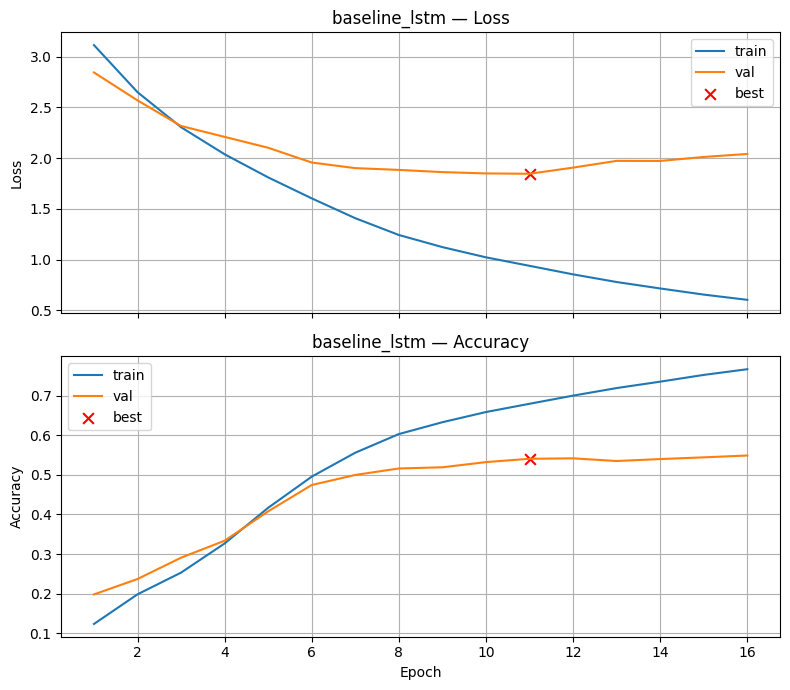

Best epoch: 11
Val loss:   1.8461
Val acc:    0.5405


In [21]:
best_ep, val_acc = plot_learning_curves(hist_lstm, "baseline_lstm")

Evaluating the LTSM Model

In [22]:
y_pred_base = evaluate_model(baseline_lstm, "baseline_lstm", X_test_vec, y_test, hist_lstm, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (2 models)
=== baseline_lstm ===
Best epoch:  11
Val acc:     0.5405  |  Val loss: 1.8461
Test acc:    0.5342  |  Test F1:  0.4616
Params:      1,319,199
Train time:  00:00:37

               precision    recall  f1-score   support

         ARTS       0.32      0.48      0.39       388
 BLACK VOICES       0.33      0.43      0.37       453
     BUSINESS       0.30      0.53      0.38       594
       COMEDY       0.37      0.40      0.38       517
        CRIME       0.43      0.54      0.48       340
      DIVORCE       0.63      0.80      0.70       342
    EDUCATION       0.30      0.45      0.36       215
ENTERTAINMENT       0.61      0.52      0.56      1606
  ENVIRONMENT       0.47      0.43      0.45       394
        FIFTY       0.11      0.31      0.16       140
 FOOD & DRINK       0.78      0.65      0.71       832
    GOOD NEWS       0.18      0.15      0.17       139
HOME & LIVING       0.51      0.33      0.40      1085
       IMPACT       0.24      0.25    

Evaluation confusion matrix for the LTSM model

In [23]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

Top 10 confused pairs (true -> predicted, count):
  POLITICS                  -> BUSINESS                   (221)
  POLITICS                  -> WORLD NEWS                 (194)
  HOME & LIVING             -> WELLNESS                   (183)
  POLITICS                  -> MEDIA                      (172)
  WELLNESS                  -> PARENTING                  (166)
  WELLNESS                  -> HOME & LIVING              (158)
  ENTERTAINMENT             -> COMEDY                     (122)
  POLITICS                  -> WOMEN                      (111)
  POLITICS                  -> BLACK VOICES               (108)
  WELLNESS                  -> FIFTY                      (96)


In [24]:
save_confused_pairs(confused,model_name="baseline_ltsm", top_n=10)

,Model,Count,True Label,Predicted Label
0,baseline_ltsm,221,POLITICS,BUSINESS
1,baseline_ltsm,194,POLITICS,WORLD NEWS
2,baseline_ltsm,183,HOME & LIVING,WELLNESS
3,baseline_ltsm,172,POLITICS,MEDIA
4,baseline_ltsm,166,WELLNESS,PARENTING
5,baseline_ltsm,158,WELLNESS,HOME & LIVING
6,baseline_ltsm,122,ENTERTAINMENT,COMEDY
7,baseline_ltsm,111,POLITICS,WOMEN
8,baseline_ltsm,108,POLITICS,BLACK VOICES
9,baseline_ltsm,96,WELLNESS,FIFTY


Trying out Bidirectional LTSM

In [25]:
# This version is with Epochs 8 and no call backs . I had multiple runs , and wanted to see the effect with call backs and without call backs
# Not anything noteworthy since this model didnt really work well
baseline_Bi_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),

    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=False)
    ),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="bilstm_model")

baseline_Bi_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


hist_Bi_lstm = baseline_Bi_lstm.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=8,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[],
    verbose=1,
)

Epoch 1/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.1603 - loss: 3.0698 - val_accuracy: 0.4118 - val_loss: 2.1382
Epoch 2/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.4160 - loss: 2.0629 - val_accuracy: 0.5111 - val_loss: 1.7765
Epoch 3/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5319 - loss: 1.6041 - val_accuracy: 0.5269 - val_loss: 1.7411
Epoch 4/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5864 - loss: 1.3573 - val_accuracy: 0.5401 - val_loss: 1.7254
Epoch 5/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6183 - loss: 1.1959 - val_accuracy: 0.5510 - val_loss: 1.7284
Epoch 6/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6437 - loss: 1.0714 - val_accuracy: 0.5610 - val_loss: 1.7187
Epoch 7/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6623 - loss: 0.9660 - val_accuracy: 0.5588 - val_loss: 1.7786
Epoch 8/8
627/627 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6805 - loss: 0.8849 - val_accuracy: 0

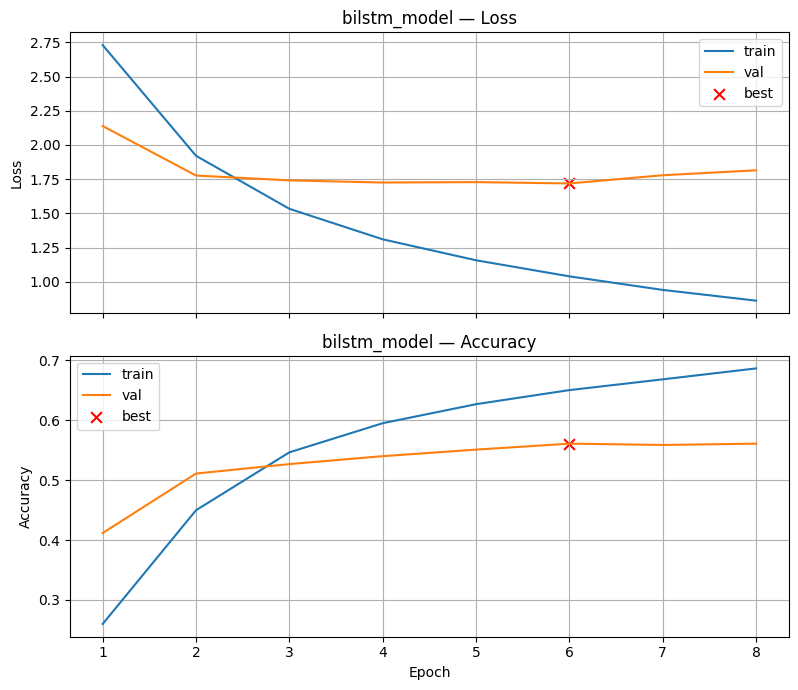

Best epoch: 6
Val loss:   1.7187
Val acc:    0.5610


In [26]:
best_ep, val_acc = plot_learning_curves(hist_Bi_lstm, "bilstm_model")

Evaluating metrics for the Bidirectional LTsM model

In [27]:

y_pred_base = evaluate_model(baseline_Bi_lstm, "bilstm_model", X_test_vec, y_test, hist_Bi_lstm, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (3 models)
=== bilstm_model ===
Best epoch:  6
Val acc:     0.5610  |  Val loss: 1.7187
Test acc:    0.5602  |  Test F1:  0.4867
Params:      1,356,319
Train time:  00:00:37

               precision    recall  f1-score   support

         ARTS       0.35      0.47      0.40       388
 BLACK VOICES       0.38      0.50      0.43       453
     BUSINESS       0.41      0.48      0.44       594
       COMEDY       0.46      0.41      0.43       517
        CRIME       0.44      0.56      0.49       340
      DIVORCE       0.65      0.73      0.69       342
    EDUCATION       0.37      0.45      0.41       215
ENTERTAINMENT       0.75      0.43      0.55      1606
  ENVIRONMENT       0.41      0.53      0.46       394
        FIFTY       0.13      0.31      0.19       140
 FOOD & DRINK       0.70      0.69      0.70       832
    GOOD NEWS       0.17      0.32      0.23       139
HOME & LIVING       0.65      0.30      0.41      1085
       IMPACT       0.22      0.42      

In [28]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

save_confused_pairs(confused,model_name="baseline_Bi_LTSM", top_n=10)

Top 10 confused pairs (true -> predicted, count):
  HOME & LIVING             -> WELLNESS                   (262)
  POLITICS                  -> WORLD NEWS                 (161)
  POLITICS                  -> BUSINESS                   (131)
  POLITICS                  -> MEDIA                      (130)
  WELLNESS                  -> PARENTING                  (101)
  POLITICS                  -> BLACK VOICES               (100)
  POLITICS                  -> IMPACT                     (97)
  ENTERTAINMENT             -> STYLE                      (95)
  ENTERTAINMENT             -> BLACK VOICES               (95)
  POLITICS                  -> ENVIRONMENT                (93)


,Model,Count,True Label,Predicted Label
0,baseline_Bi_LTSM,262,HOME & LIVING,WELLNESS
1,baseline_Bi_LTSM,161,POLITICS,WORLD NEWS
2,baseline_Bi_LTSM,131,POLITICS,BUSINESS
3,baseline_Bi_LTSM,130,POLITICS,MEDIA
4,baseline_Bi_LTSM,101,WELLNESS,PARENTING
5,baseline_Bi_LTSM,100,POLITICS,BLACK VOICES
6,baseline_Bi_LTSM,97,POLITICS,IMPACT
7,baseline_Bi_LTSM,95,ENTERTAINMENT,STYLE
8,baseline_Bi_LTSM,95,ENTERTAINMENT,BLACK VOICES
9,baseline_Bi_LTSM,93,POLITICS,ENVIRONMENT


Both LTSM and Bidirection LTSM didnt perform any better than Baseline. So going back to simpler Basic Baseline Model and adding regularization parameters like drop out , batch normalization and additional dense layers

In [29]:
baseline_withDroput_withoutLTSM = tf.keras.Sequential([
    tf.keras.layers.Embedding(MAX_TOKENS, 64),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(128, activation="relu"),   #  extra dense layer
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(num_classes, activation="softmax"),
], name="baseline_withDroput_withoutLTSM")

baseline_withDroput_withoutLTSM.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_withDroput_withoutLTSM.summary()

Model: "baseline_withDroput_withoutLTSM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
hist_withDroput_withoutLTSM = baseline_withDroput_withoutLTSM.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=15,
    batch_size=BATCH,
    class_weight=class_weights,
    callbacks=[],
    verbose=1,
)

Epoch 1/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1783 - loss: 3.1778 - val_accuracy: 0.5128 - val_loss: 1.9993
Epoch 2/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4775 - loss: 1.8703 - val_accuracy: 0.5225 - val_loss: 1.7523
Epoch 3/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5357 - loss: 1.5522 - val_accuracy: 0.5427 - val_loss: 1.6782
Epoch 4/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5723 - loss: 1.3631 - val_accuracy: 0.5164 - val_loss: 1.8444
Epoch 5/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5914 - loss: 1.2436 - val_accuracy: 0.5459 - val_loss: 1.7184
Epoch 6/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6067 - loss: 1.1511 - val_accuracy: 0.5487 - val_loss: 1.7563
Epoch 7/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6229 - loss: 1.0804 - val_accuracy: 0.5266 - val_loss: 1.8850
Epoch 8/15
627/627 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6349 - loss: 1.0138 - val_accuracy: 0.

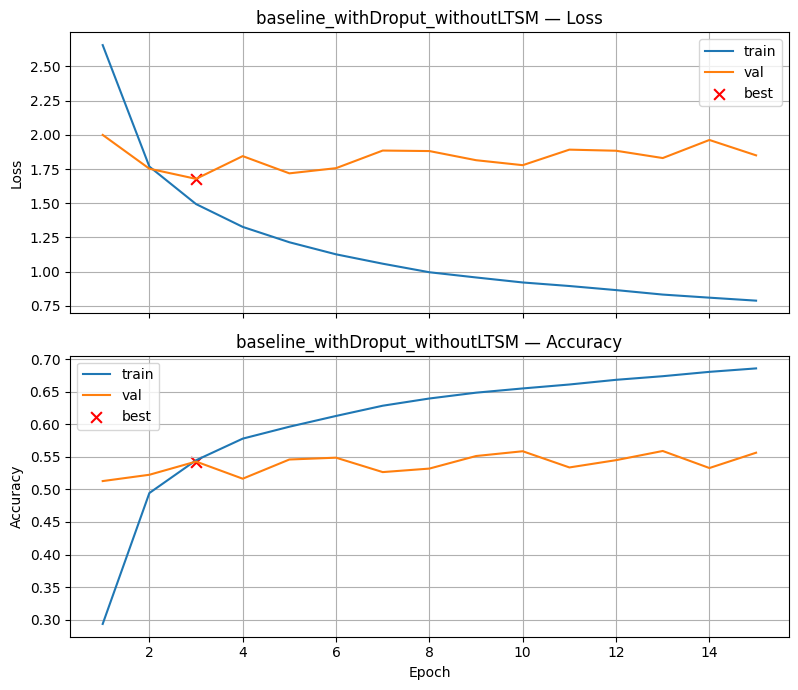

Best epoch: 3
Val loss:   1.6782
Val acc:    0.5427


In [31]:
best_ep, val_acc = plot_learning_curves(hist_withDroput_withoutLTSM, "baseline_withDroput_withoutLTSM")

Evaluating performance from above model

In [32]:
t0 = time.time()
train_time = time.time() - t0
y_pred_base = evaluate_model(baseline_withDroput_withoutLTSM, "baseline_withDroput_withoutLTSM", X_test_vec, y_test, hist_withDroput_withoutLTSM, train_time)
print()
print(classification_report(y_test, y_pred_base, target_names=class_names, zero_division=0))

Results saved (4 models)
=== baseline_withDroput_withoutLTSM ===
Best epoch:  3
Val acc:     0.5427  |  Val loss: 1.6782
Test acc:    0.5536  |  Test F1:  0.4889
Params:      1,299,359
Train time:  00:00:00

               precision    recall  f1-score   support

         ARTS       0.37      0.51      0.43       388
 BLACK VOICES       0.41      0.47      0.44       453
     BUSINESS       0.37      0.56      0.45       594
       COMEDY       0.47      0.40      0.43       517
        CRIME       0.44      0.54      0.48       340
      DIVORCE       0.60      0.77      0.67       342
    EDUCATION       0.30      0.49      0.37       215
ENTERTAINMENT       0.71      0.49      0.58      1606
  ENVIRONMENT       0.41      0.51      0.45       394
        FIFTY       0.20      0.32      0.25       140
 FOOD & DRINK       0.70      0.76      0.73       832
    GOOD NEWS       0.20      0.22      0.21       139
HOME & LIVING       0.60      0.32      0.42      1085
       IMPACT       0

In [33]:
cm = confusion_matrix(y_test, y_pred_base)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
for count, true, pred in confused[:10]:
    print(f"  {true:25s} -> {pred:25s}  ({count})")

save_confused_pairs(confused,model_name="baseline_withDroput_withoutLTSM", top_n=10)

Top 10 confused pairs (true -> predicted, count):
  POLITICS                  -> WORLD NEWS                 (331)
  HOME & LIVING             -> WELLNESS                   (223)
  POLITICS                  -> BUSINESS                   (188)
  POLITICS                  -> MEDIA                      (123)
  ENTERTAINMENT             -> STYLE                      (122)
  POLITICS                  -> WOMEN                      (119)
  ENTERTAINMENT             -> ARTS                       (99)
  POLITICS                  -> ENVIRONMENT                (87)
  WELLNESS                  -> IMPACT                     (86)
  POLITICS                  -> BLACK VOICES               (86)


,Model,Count,True Label,Predicted Label
0,baseline_withDroput_withoutLTSM,331,POLITICS,WORLD NEWS
1,baseline_withDroput_withoutLTSM,223,HOME & LIVING,WELLNESS
2,baseline_withDroput_withoutLTSM,188,POLITICS,BUSINESS
3,baseline_withDroput_withoutLTSM,123,POLITICS,MEDIA
4,baseline_withDroput_withoutLTSM,122,ENTERTAINMENT,STYLE
5,baseline_withDroput_withoutLTSM,119,POLITICS,WOMEN
6,baseline_withDroput_withoutLTSM,99,ENTERTAINMENT,ARTS
7,baseline_withDroput_withoutLTSM,87,POLITICS,ENVIRONMENT
8,baseline_withDroput_withoutLTSM,86,WELLNESS,IMPACT
9,baseline_withDroput_withoutLTSM,86,POLITICS,BLACK VOICES


In [34]:
load_results()

Restored 4 results from results/ms2_results.json:
  Baseline (Emb+AvgPool): test_acc=0.5638, test_f1=0.4987
  baseline_lstm: test_acc=0.5342, test_f1=0.4616
  bilstm_model: test_acc=0.5602, test_f1=0.4867
  baseline_withDroput_withoutLTSM: test_acc=0.5536, test_f1=0.4889


### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**
After establishing the baseline (Embedding → GlobalAveragePooling → Dense → Softmax), we explored three architectural modifications to address its main limitation: loss of word order and contextual information.

First, we replaced the GlobalAveragePooling layer with an LSTM(64) layer. The motivation was to capture sequential dependencies in text, allowing the model to distinguish between phrases where word order matters. All other components, including early stopping, were kept consistent to isolate the effect of the LSTM.

Second, we extended this idea by using a Bidirectional LSTM with dropout (0.5). The bidirectional structure allows the model to process text in both forward and backward directions, theoretically improving context understanding. Dropout was introduced to mitigate overfitting, which was already observed in the baseline.

Finally, we revisited the baseline architecture and enhanced it by adding Batch Normalization, Dropout, and an additional Dense layer, while removing early stopping. This approach focused on improving generalization and optimization stability without increasing sequence modeling complexity, effectively strengthening the original architecture rather than replacing it.


2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**
The training results for the modified architectures are summarized in the summary table and performance charts.

The LSTM(64) model performed slightly worse than the baseline. Its validation accuracy reached 0.540 (best epoch 11), with a test accuracy of 0.534 and test F1 of 0.462. While the model learned meaningful patterns, it did not improve over the baseline, suggesting that the added sequential modeling complexity did not provide additional signal for this short-text task.

The Bidirectional LSTM model showed comparable performance to the baseline, achieving test accuracy of 0.560 and F1 of 0.487. The bidirectional structure captured more context than the standard LSTM but still did not surpass the simpler model.

The enhanced baseline model (BatchNorm + Dropout + Dense) achieved test accuracy of 0.554 and F1 of 0.489, which are close to the original baseline. While validation accuracy (0.543) was slightly lower, the test metrics suggest that the added regularization provided no meaningful benefit.

Overall, none of the from-scratch architectural modifications improved upon the baseline model. All four from-scratch models clustered within a narrow 53-56% accuracy band, suggesting a performance ceiling for models trained on randomly initialized embeddings.

3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**
The results indicate that none of the from-scratch architectural modifications outperformed the baseline, though unlike an earlier run where the LSTM catastrophically failed, all models achieved reasonable performance in the 53-56% accuracy range.

The standard LSTM performed slightly below the baseline (0.534 vs 0.564 accuracy), suggesting that sequential modeling adds complexity without meaningful benefit for this short-text dataset. The Bidirectional LSTM achieved accuracy comparable to the baseline (0.560) but its F1 score (0.487) remained slightly lower, indicating no meaningful gain.

The enhanced baseline with Batch Normalization and Dropout also failed to improve results (0.554 accuracy, 0.489 F1), suggesting that the original model was already sufficiently regularized.

Overall, the findings show that the ~56% accuracy ceiling for from-scratch models reflects a representation limitation — randomly initialized embeddings can only capture keyword-level features, not the deeper semantic relationships needed to distinguish between overlapping categories. This motivates the use of pretrained language models in Problem 4.

4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**
This experiment highlights that increasing model complexity does not necessarily lead to better performance. More advanced architectures like LSTM and Bidirectional LSTM introduced additional parameters and training challenges but did not outperform the simpler baseline. In fact, the standard LSTM significantly underperformed, indicating that added complexity can make optimization more difficult without providing meaningful gains.

The results also show that regularization must be applied carefully. Adding Dropout and Batch Normalization did not improve performance, suggesting that the baseline model was already well-balanced and that excessive regularization or architectural changes can disrupt effective learning.




## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


**Note (Sergey):** If training feels slow on Apple Silicon, try setting `USE_GPU = True` in the setup cell and restarting the kernel. BERT-scale models benefit from Metal GPU, unlike the smaller P2-P3 models. TF locks the device config at startup, so a kernel restart is needed to switch.

Fastest BERT setup for HuffPost
Strategy:
- DistilBERT pretrained checkpoint
- Train on a subset first for speed
- Freeze most of backbone
- Unfreeze only top 2 transformer blocks
- Small LR for stability


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    TFAutoModelForSequenceClassification,
    create_optimizer
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [36]:
## Configure
checkpoint = "distilbert-base-uncased"
MAX_LEN = 64
BATCH = 128
EPOCHS = 16
LR = 2e-5           # small LR for partial fine-tuning
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
SUBSET_FRAC = 0.50  # fastest practical run; use 1.00 for final comparison

In [37]:
## Stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 160290
Val size: 20036
Test size: 20037


In [38]:
## Speed subset on training only

subset_frac = 0.50
n_train = len(X_train)
subset_size = int(n_train * subset_frac)

rng = np.random.default_rng(SEED)
subset_idx = rng.choice(n_train, size=subset_size, replace=False)

X_train_sub = X_train[subset_idx]
y_train_sub = y_train[subset_idx]

In [39]:
## Tokenization for distilBERT
## Hugging Face recommends AutoTokenizer for sequence classification

tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def tokenize_texts(texts, tokenizer, max_length=64):
    return tokenizer(
        list(texts),
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="np"
    )

X_train_tok = tokenize_texts(X_train_sub, tokenizer, MAX_LEN)
X_val_tok   = tokenize_texts(X_val, tokenizer, MAX_LEN)
X_test_tok  = tokenize_texts(X_test, tokenizer, MAX_LEN)

y_train_final = y_train_sub
y_val_final   = y_val
y_test_final  = y_test

print("Train token shapes:", {k: v.shape for k, v in X_train_tok.items()})
print("Train labels shape:", y_train_final.shape)
print("Val labels shape:", y_val_final.shape)
print("Test labels shape:", y_test_final.shape)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train token shapes: {'input_ids': (80145, 64), 'attention_mask': (80145, 64)}
Train labels shape: (80145,)
Val labels shape: (20036,)
Test labels shape: (20037,)


In [40]:
## tf.data pipelines

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_train_tok),
    y_train_final
)).shuffle(len(y_train_final), seed=SEED).batch(BATCH).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_val_tok),
    y_val_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((
    dict(X_test_tok),
    y_test_final
)).batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [41]:
## Class weights for imbalance for distilBERT

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_final)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_final
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_arr)}
print("Class weights:", class_weights)


Class weights: {0: 1.657258064516129, 1: 1.4370887051946422, 2: 1.0973355605454844, 3: 1.2495517547825816, 4: 1.9178950894993778, 5: 1.933674331073419, 6: 2.934531873604042, 7: 0.40662513064566863, 8: 1.6239463446263576, 9: 4.633194588969823, 10: 0.7805925666199158, 11: 4.616647465437788, 12: 0.5976242673705875, 13: 1.8707109845478735, 14: 5.632511068943707, 15: 2.28587319243604, 16: 3.7252486752812124, 17: 0.5141850796828086, 18: 0.19624431308981033, 19: 1.0333023903457879, 20: 2.5775898112115265, 21: 2.8193266964505574, 22: 1.3423274042809767, 23: 0.545772130176306, 24: 3.126145804891368, 25: 0.6445581103578063, 26: 1.7270023918805353, 27: 2.402716153015949, 28: 0.37044312661486767, 29: 1.8400872460107909, 30: 0.7738169951048073}


In [42]:
## Load pretrained DistilBERT model

id2label = {i: name for name, i in label2id.items()}

p4_model = TFAutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [43]:
## learning strategy - Freeze most of backbone, unfreeze only top 2 blocks
## BUG FIX: In TF/Keras, setting parent.trainable=False overrides children.
## Must freeze individual layers, NOT the parent model.

p4_model.distilbert.trainable = True  # keep parent trainable so children are respected

# Freeze the embedding layer
p4_model.distilbert.embeddings.trainable = False

# Freeze all transformer blocks first, then unfreeze top 2
for layer in p4_model.distilbert.transformer.layer:
    layer.trainable = False
for layer in p4_model.distilbert.transformer.layer[-2:]:
    layer.trainable = True

# Ensure classification head remains trainable
if hasattr(p4_model, "pre_classifier"):
    p4_model.pre_classifier.trainable = True
if hasattr(p4_model, "classifier"):
    p4_model.classifier.trainable = True
if hasattr(p4_model, "dropout"):
    p4_model.dropout.trainable = True

# Optional: inspect trainable variables
_ = p4_model(p4_model.dummy_inputs)  # build model once

print("\nTrainable variables:")
for v in p4_model.trainable_variables[:20]:
    print(v.name, v.shape)
print("Total trainable vars:", len(p4_model.trainable_variables))


Trainable variables:
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/q_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/q_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/k_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/k_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/v_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/v_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/out_lin/kernel:0 (768, 768)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/attention/out_lin/bias:0 (768,)
tf_distil_bert_for_sequence_classification/distilbert/transformer/layer_._4/sa_layer_norm/gamma:0 (768

In [44]:
## Optimizer / LR schedule for distilBERT
## Smaller LR for partial fine-tuning

import math
steps_per_epoch = math.ceil(len(y_train_final) / BATCH)
num_train_steps = steps_per_epoch * EPOCHS
num_warmup_steps = int(WARMUP_RATIO * num_train_steps)

optimizer, lr_schedule = create_optimizer(
    init_lr=LR,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps,
    weight_decay_rate=WEIGHT_DECAY,
)

p4_model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)


In [45]:
## Callbacks

# bug fixed here :
import tf_keras
es = tf_keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


## Train

t0 = time.time()

history = p4_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[es],
    verbose=1
)

train_time = time.time() - t0
print(f"\nTraining time: {train_time/60:.2f} minutes")

## -------------------------------------------------------------------
val_logits = p4_model.predict(val_ds).logits
test_logits = p4_model.predict(test_ds).logits

val_pred = np.argmax(val_logits, axis=1)
test_pred = np.argmax(test_logits, axis=1)

val_acc = accuracy_score(y_val_final, val_pred)
val_f1_macro = f1_score(y_val_final, val_pred, average="macro")
val_f1_weighted = f1_score(y_val_final, val_pred, average="weighted")

test_acc = accuracy_score(y_test_final, test_pred)
test_f1_macro = f1_score(y_test_final, test_pred, average="macro")
test_f1_weighted = f1_score(y_test_final, test_pred, average="weighted")

print("\nValidation metrics")
print("Accuracy:", round(val_acc, 4))
print("Macro F1:", round(val_f1_macro, 4))
print("Weighted F1:", round(val_f1_weighted, 4))

print("\nTest metrics")
print("Accuracy:", round(test_acc, 4))
print("Macro F1:", round(test_f1_macro, 4))
print("Weighted F1:", round(test_f1_weighted, 4))

print("\nClassification report (test)")
print(classification_report(
    y_test_final,
    test_pred,
    target_names=[id2label[i] for i in range(num_classes)],
    digits=4
))

##----------------------------------------------
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

print("\nBalanced Accuracy")
print("Validation:", round(balanced_accuracy_score(y_val_final, val_pred), 4))
print("Test:", round(balanced_accuracy_score(y_test_final, test_pred), 4))

cm = confusion_matrix(y_test_final, test_pred)
print("\nConfusion matrix shape:", cm.shape)

Epoch 1/16
627/627 [==============================] - 367s 572ms/step - loss: 2.6688 - accuracy: 0.3208 - val_loss: 1.6558 - val_accuracy: 0.5789
Epoch 2/16
627/627 [==============================] - 356s 567ms/step - loss: 1.3928 - accuracy: 0.6285 - val_loss: 1.1784 - val_accuracy: 0.6676
Epoch 3/16
627/627 [==============================] - 354s 564ms/step - loss: 1.1466 - accuracy: 0.6751 - val_loss: 1.0965 - val_accuracy: 0.6855
Epoch 4/16
627/627 [==============================] - 354s 564ms/step - loss: 1.0582 - accuracy: 0.6970 - val_loss: 1.0478 - val_accuracy: 0.6933
Epoch 5/16
627/627 [==============================] - 356s 568ms/step - loss: 0.9982 - accuracy: 0.7095 - val_loss: 1.0272 - val_accuracy: 0.6994
Epoch 6/16
627/627 [==============================] - 354s 565ms/step - loss: 0.9515 - accuracy: 0.7202 - val_loss: 1.0141 - val_accuracy: 0.7009
Epoch 7/16
627/627 [==============================] - 356s 568ms/step - loss: 0.9100 - accuracy: 0.7312 - val_loss: 1.0098 -

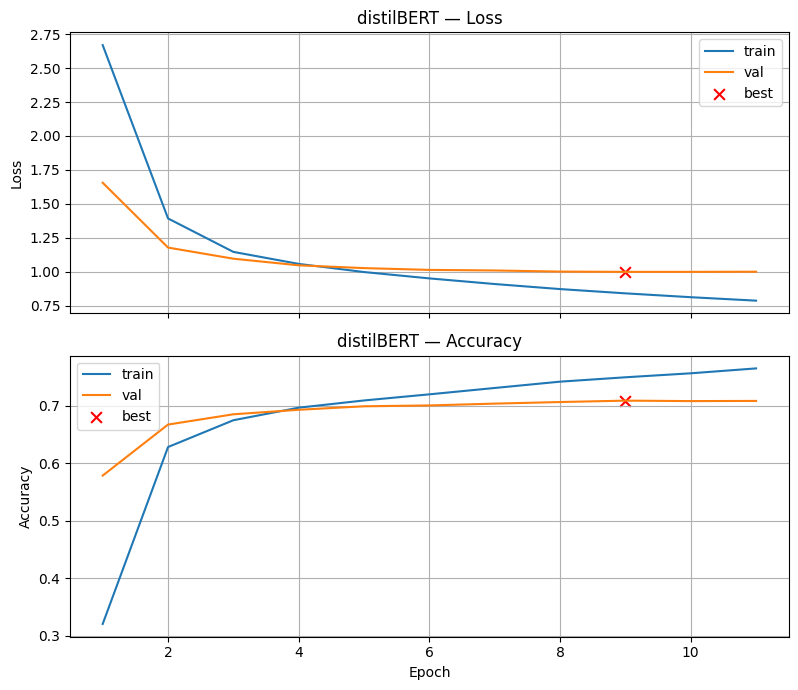

Best epoch: 9
Val loss:   0.9996
Val acc:    0.7092


In [46]:
best_ep, val_acc = plot_learning_curves(history, "distilBERT")

In [47]:
#Redo Evaluate Model function to handle DistilBERT
def evaluate_model(model, name, X_te, y_te, hist, train_time, batch_size=512):
    preds = model.predict(X_te, batch_size=batch_size, verbose=0)

    # Handle Hugging Face TF models that return an object with `.logits`
    if hasattr(preds, "logits"):
        y_pred = np.argmax(preds.logits, axis=-1)
    else:
        y_pred = np.argmax(preds, axis=-1)

    test_acc = float(np.mean(y_pred == y_te))
    test_f1 = float(f1_score(y_te, y_pred, average="macro"))

    val_losses = hist.history["val_loss"]
    best_epoch = int(np.argmin(val_losses)) + 1
    val_acc = float(hist.history["val_accuracy"][best_epoch - 1])
    val_loss = float(val_losses[best_epoch - 1])

    results[name] = {
        "val_acc": val_acc,
        "val_loss": val_loss,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "params": model.count_params(),
        "train_time": train_time,
    }
    save_results()
    return y_pred

In [48]:
y_pred_distilbert = evaluate_model(
    model=p4_model,
    name="DistilBERT",
    X_te=test_ds,
    y_te=y_test_final,
    hist=history,
    train_time=train_time,
    batch_size=BATCH
)

Results saved (5 models)


In [49]:


cm = confusion_matrix(y_test_final, y_pred_distilbert)

confused = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 0:
            confused.append((cm[i, j], class_names[i], class_names[j]))
confused.sort(reverse=True)

print("Top 10 confused pairs (true -> predicted, count):")
# for count, true, pred in confused[:10]:
#     print(f"  {true:25s} -> {pred:25s}  ({count})”)

save_confused_pairs(confused,model_name="distilBERT", top_n=10)

Top 10 confused pairs (true -> predicted, count):


,Model,Count,True Label,Predicted Label
0,distilBERT,233,HOME & LIVING,WELLNESS
1,distilBERT,84,POLITICS,WORLD NEWS
2,distilBERT,74,COMEDY,ENTERTAINMENT
3,distilBERT,71,ENTERTAINMENT,COMEDY
4,distilBERT,70,BLACK VOICES,ENTERTAINMENT
5,distilBERT,68,PARENTING,WELLNESS
6,distilBERT,65,WORLD NEWS,POLITICS
7,distilBERT,65,POLITICS,BLACK VOICES
8,distilBERT,55,POLITICS,MEDIA
9,distilBERT,55,BLACK VOICES,POLITICS


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**

The pretraining architecture we selected was `distilBERT`. This choice was motivated by this architecture providing the best balance of a quicker run time while not sacrificing accuracy when compared to `BERT` and `RoBERTa`. `BERT` is a very heavy model that takes a very long time to run due to having about 40% more parameters than `distilBERT`. Another advantage `distilBERT` has is that it stabilizes faster and generally does not need as many epochs to reach solid validation performance than both `BERT` and `RoBERTa`. Also, `RoBERTa` is an even heavier model than `BERT` which just is not practical for a short text dataset.


2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it.

4.2. **Your answer here:**

The fine tuning strategy we chose was freezing the backbone and unfreezing top 2 transformer blocks. This was chosen because the HuffPost dataset is not a dataset that requires deep reasoning when training a model. Freezing the backbone preserves the required knowledge. Unfreezing the top 2 layers was chosen because the lower layers of the transformer tend to be grammatical or syntax which we are not concerned with for the HuffPost dataset. The upper layers are the topics/categories which we are concerned with. A smaller learning rate was also applied so it can gently adapt to the features.

From the EDA, there was severe class imbalance which rules out full fine-tuning since that strategy overfits the dominant classes and cause unstabilized training.



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**

The `distilBERT` model achieved a validation accuracy of 0.709, test accuracy of 0.708, and a macro F1 score of 0.621 — substantially outperforming all from-scratch models.

In comparison: the baseline had test accuracy of 0.564 and F1 of 0.499, the BiLSTM had 0.560 and 0.487, and the enhanced baseline had 0.554 and 0.489. DistilBERT improved test accuracy by 14.4 percentage points and macro F1 by 12.2 percentage points over the best from-scratch model.

DistilBERT improved F1 on all 31 categories compared to the baseline. The most dramatic gains were on categories requiring contextual understanding: EDUCATION (0.41 → 0.56), ARTS (0.46 → 0.62), ENTERTAINMENT (0.56 → 0.74), and SCIENCE (0.37 → 0.65). DistilBERT also achieved the lowest validation loss (0.9996), indicating well-calibrated probability outputs. The pretrained language representations proved decisive in breaking through the ~56% accuracy ceiling that all from-scratch models shared.

4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models.

4.4. **Your answer here:**

The `distilBERT` model differed significantly from the previous models in computational requirements. Each epoch took ~356 seconds on a Kaggle T4 GPU, compared to ~3-5 seconds per epoch for the from-scratch models. Total training time was 65 minutes for 11 epochs (early stopping triggered with patience=2, best epoch 9), compared to under 37 seconds for the baseline.

Despite having 67M total parameters (52x more than the baseline), only ~14.2M were trainable due to our freezing strategy (top 2 transformer blocks + classification head = 36 trainable variable tensors). Training was performed on a 50% stratified subset (80,145 samples) to manage compute time.

Convergence was notably faster in terms of epochs: DistilBERT reached 0.579 validation accuracy by epoch 1 — already surpassing the best validation accuracy of any from-scratch model. By epoch 9, it peaked at 0.709. Prior to selecting `distilBERT`, memory was a limitation when trying `BERT`. `distilBERT` caused a spike in RAM usage when initially creating the model but decreased once training began.

## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report.

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

**Create Summary Table**

In [50]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load results JSON
with open("results/ms2_results.json") as f:
    results = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(results).T.reset_index()
df = df.rename(columns={"index": "model"})

# Load confused categories CSV
confused_df = pd.read_csv("confused_pairs.csv")

summary_cols = ["model", "test_acc", "test_f1", "val_acc", "best_epoch", "params", "train_time"]
summary_table = df[summary_cols].sort_values(by="test_f1", ascending=False)

summary_table

,model,test_acc,test_f1,val_acc,best_epoch,params,train_time
4,DistilBERT,0.707691,0.620640,0.709223,9.0,66977311.0,3919.706711
0,Baseline (Emb+AvgPool),0.563757,0.498657,0.561290,11.0,1286175.0,37.263052
3,baseline_withDroput_withoutLTSM,0.553626,0.488948,0.542723,3.0,1299359.0,0.000039
2,bilstm_model,0.560214,0.486682,0.560990,6.0,1356319.0,37.263052
1,baseline_lstm,0.534212,0.461616,0.540477,11.0,1319199.0,37.263052


In [51]:
summary_table.to_csv("summary_table.csv", index=False)

**Visualization: Accuracy & F1 Comparison**

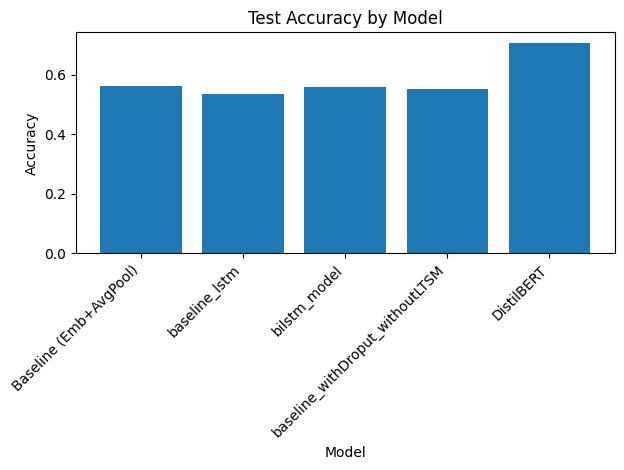

In [52]:
plt.figure()
plt.bar(df["model"], df["test_acc"])
plt.xticks(rotation=45, ha='right')
plt.title("Test Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

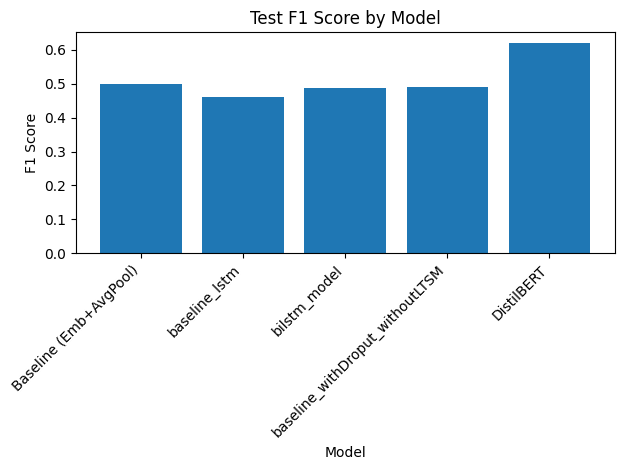

In [53]:
plt.figure()
plt.bar(df["model"], df["test_f1"])
plt.xticks(rotation=45, ha='right')
plt.title("Test F1 Score by Model")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.tight_layout()
plt.show()

**Training Time Comparison**

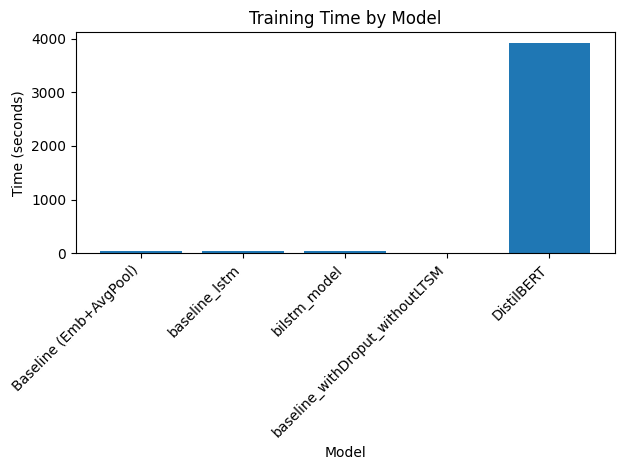

In [54]:
plt.figure()
plt.bar(df["model"], df["train_time"])
plt.xticks(rotation=45, ha='right')
plt.title("Training Time by Model")
plt.xlabel("Model")
plt.ylabel("Time (seconds)")
plt.tight_layout()
plt.show()

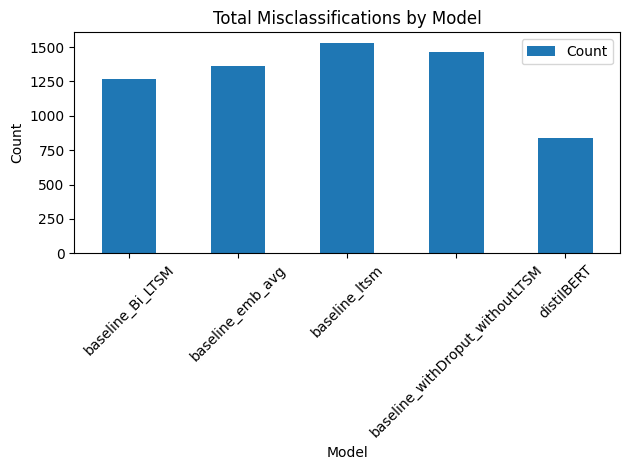

In [55]:
confused_df.head()

if "Model" in confused_df.columns:
    pivot = confused_df.pivot_table(index="Model", values="Count", aggfunc="sum")
    pivot.plot(kind="bar")
    plt.title("Total Misclassifications by Model")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [56]:
confused_df.head()

,Model,Count,True Label,Predicted Label
0,baseline_emb_avg,210,HOME & LIVING,WELLNESS
1,baseline_emb_avg,196,ENTERTAINMENT,COMEDY
2,baseline_emb_avg,188,POLITICS,WORLD NEWS
3,baseline_emb_avg,128,POLITICS,MEDIA
4,baseline_emb_avg,123,POLITICS,COMEDY


**Compare SAME Categories Across Models**

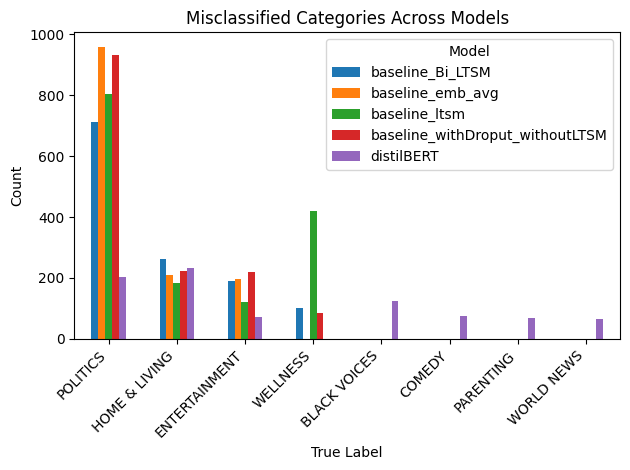

In [57]:
pivot = confused_df.pivot_table(
    index="True Label",
    columns="Model",
    values="Count",
    aggfunc="sum",
    fill_value=0
)

# Focus on most problematic categories
top_categories = pivot.sum(axis=1).sort_values(ascending=False).head(10).index
pivot_top = pivot.loc[top_categories]

pivot_top.plot(kind="bar")
plt.title("Misclassified Categories Across Models")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Combined Accuracy + F1 Chart**

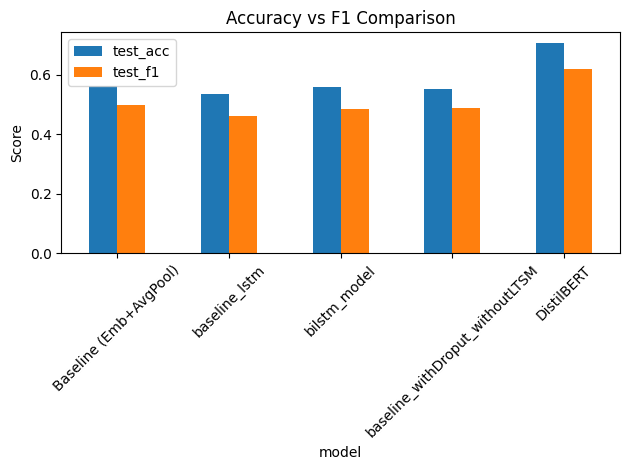

In [58]:
df_plot = df.set_index("model")[["test_acc", "test_f1"]]

df_plot.plot(kind="bar")
plt.title("Accuracy vs F1 Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

The quantitative comparison of all models is presented above in the Accuracy vs F1 Comparison chart and Test Accuracy / Test F1 bar plots.

From these results, the DistilBERT model achieved the best overall performance by a wide margin, with the highest test accuracy (0.708), highest test F1 score (0.621), and highest validation accuracy (0.709). The four from-scratch models (Baseline, LSTM, BiLSTM, Enhanced Baseline) all clustered between 53-56% accuracy and 46-50% F1, forming a distinct lower performance tier.

This two-tier pattern is clearly visible in the F1 comparison chart, where DistilBERT stands apart, and in the Accuracy vs F1 grouped bar chart, which shows DistilBERT achieved the most balanced performance across classes.

The success of DistilBERT can be attributed to:

- Pretrained contextual embeddings that capture semantic relationships beyond keyword matching
- The ability to distinguish between semantically similar categories (e.g., POLITICS vs WORLD NEWS) that from-scratch models could not
- Fine-tuning the top 2 transformer blocks, which adapted the model's topical representations to the HuffPost category structure
- Improved F1 on all 31 categories compared to the baseline, with no class receiving zero predictions

2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

The trade-offs between complexity, accuracy, and efficiency are illustrated in the Params vs F1 scatter plot and the Training Time comparison chart.

**Baseline model:**
- Low complexity (1.3M parameters)
- Best performance among from-scratch models (F1 0.499)
- Fast training (37 seconds)
- Best efficiency within the from-scratch tier

**BiLSTM model:**
- Moderate complexity (1.4M parameters)
- Comparable accuracy but slightly lower F1 than baseline
- Similar training time
- Marginal gains do not justify added complexity

**DistilBERT:**
- Very high complexity (67M parameters, 52x more than baseline)
- Significantly longer training time (65 minutes vs 37 seconds)
- Far superior performance: +14.4pp accuracy, +12.2pp F1 over baseline
- The compute cost is justified by the substantial and consistent improvement across nearly all categories

**LSTM model:**
- Moderate complexity but slightly worse performance than baseline
- Indicates that sequential modeling alone does not help for this short-text task

Overall, the results show two distinct tiers: from-scratch models clustered at ~54-56% accuracy regardless of architecture, while pretrained DistilBERT broke through to 71%. The 105x training time increase is a meaningful cost, but the 14+ percentage point accuracy gain justifies it for production use cases.

3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

Error patterns are illustrated using the Top Confusion Pairs chart and Misclassified Categories bar chart

Across all models, certain categories were consistently misclassified, as shown in the heatmap of misclassifications across models. This indicates that errors are not model-specific but rather stem from intrinsic dataset challenges.

Key observations:

- Semantically similar categories (e.g., closely related topics) were frequently confused, as seen in the Top Confusion Pairs chart
- The Top Misclassified Categories chart shows that a small subset of categories accounts for a large portion of errors
- The heatmap reveals that these problematic categories persist across all models, including more complex ones

This suggests:

High overlap in vocabulary between categories
Ambiguity in labeling
Limited contextual information in the input text



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model.


5.4 **Your answer here:**
Based on the results, **DistilBERT** is selected for further development, as it clearly outperforms all from-scratch models on both accuracy (0.708) and macro F1 (0.621).

The decision is supported by:

- Highest F1 score and accuracy in the comparison charts
- Improved performance on all 31 categories vs the baseline
- Lowest validation loss (0.9996), indicating well-calibrated predictions
- The pretrained representations broke through the ~56% ceiling that all from-scratch models shared

**Planned Improvements**

**Full-Dataset Training**
- Train on 100% of training data instead of the 50% subset
- Should particularly help minority classes with limited examples

**Further Category Merging**
- Analyze persistent confusion pairs (HOME & LIVING / WELLNESS, ENTERTAINMENT / COMEDY)
- Evaluate whether additional merges improve overall quality

**Hyperparameter Tuning**
- Experiment with unfreezing more transformer blocks (top 3 or 4)
- Tune learning rate schedule and explore longer max_length (96 or 128)
- Use validation F1 as the tuning criterion instead of validation loss

**Data-Centric Improvements**
- Clean noisy or ambiguous samples identified in the confusion analysis
- Explore text augmentation for minority classes (synonym replacement, back-translation)

### Final Question: Describe what use you made of generative AI tools in preparing this Milestone.

This response is a consolidation of all the 3 team members based on how each of us were each of the problems

**AI tools used:** Claude Code (Anthropic, Opus model) via CLI , codex and chatgpt

**How:** Technical support — environment setup (resolving TensorFlow/tensorflow-metal version conflicts, configuring GPU vs CPU execution for Apple Silicon), debugging runtime errors (PyArrow array indexing incompatibility with sklearn), and notebook infrastructure (results persistence across kernel restarts, tf.data pipeline setup).
Summarization - Used Chatgpt to provide good summarization of the results based on the outputs which were consolidated by the code (results.json and confusion.csv)

**Why:** Platform-specific issues (M4 Pro / Metal GPU) are not covered in course materials and required troubleshooting outside the scope of the assignments.

**Full conversation log:** Available upon request.